# Minimal Component Separation

We observe

$$
d = s + n_0,
$$

where $s$ is the unknown signal and $n_0$ is one realization of white noise. We also have independent noise realizations $n^{(i)}$ drawn from the same distribution. The goal is to estimate $s$ by optimizing a candidate map $u$.

The notebook mirrors `toy_compsep.py`: one stochastic L-BFGS update per iteration, a fresh noise batch at every iteration, periodic boundary conditions controlled by one flag, optional power-spectrum constraints, and Nyquist filtering only after optimization.

## Parameters

All choices that should be changed are collected here. The pedagogical defaults use 100 available noise maps, batches of 15, and 60 optimizer iterations.

In [19]:
SEED = 2
DEVICE = "cuda:0"          # use "cpu" if needed
DTYPE = "float64"          # "float64" or "float32"

N_NOISE = 100              # bank of independent noise maps
BATCH_SIZE = 15            # fresh noise maps per iteration
N_ITER = 60                # one L-BFGS step per iteration
OPTIMIZER_LR = 1.0

WTYPE = "Bump-Steerable"
PBC = True                 # periodic boundary conditions
COMPUTE_PS = False         # include power-spectrum constraints in Phi
APPLY_NYQUIST_AFTER = True # applied only after optimization

## Setup

We use the current `STL_main` torch backend. The dtype must set both the real and complex torch defaults, otherwise FFT-based gradients can fail or silently mix precisions.

In [20]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd().resolve()
if not (ROOT / "STL_main").exists():
    for parent in ROOT.parents:
        if (parent / "STL_main").exists():
            ROOT = parent
            break
sys.path.insert(0, str(ROOT))

import STL_main.torch_backend as bk
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch as DataClass


def torch_dtype(name):
    name = name.lower()
    if name in {"float64", "fp64", "double"}:
        return torch.float64
    if name in {"float32", "fp32", "single"}:
        return torch.float32
    raise ValueError("DTYPE must be float64 or float32")


device = torch.device(DEVICE if torch.cuda.is_available() or DEVICE == "cpu" else "cpu")
dtype = torch_dtype(DTYPE)

if hasattr(bk, "set_default_device"):
    bk.set_default_device(device)
else:
    bk._DEFAULT_DEVICE = device
bk._DEFAULT_DTYPE = dtype
bk._DEFAULT_COMPLEX_DTYPE = torch.complex64 if dtype == torch.float32 else torch.complex128

torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
print(f"device={device}, dtype={dtype}, PBC={PBC}, compute_PS={COMPUTE_PS}")

device=cpu, dtype=torch.float64, PBC=True, compute_PS=False


## Toy Data

For the toy problem only, we know the true $s$. We form one observed map

$$
d = s + n_0,
$$

and a bank $\\{n^{(i)}\\}_{i=1}^{N_{\rm noise}}$ of independent noise maps. The optimizer sees $d$ and the noise bank, not the true $s$.

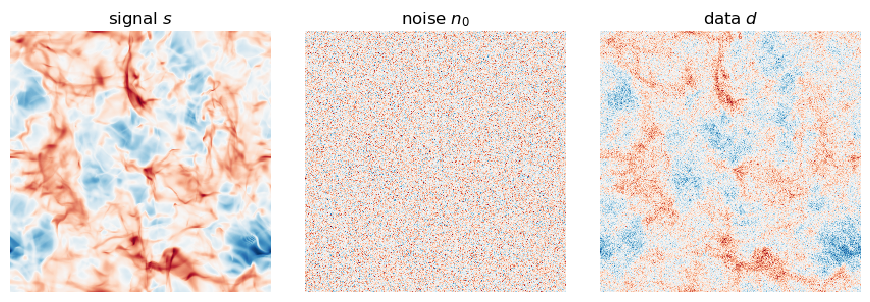

In [21]:
s = np.load(ROOT / "data/test/Turb_6.npy")[0].astype(np.float64)
H, W = s.shape
noise_std = float(np.std(s))

n0 = rng.standard_normal((H, W)).astype(np.float64) * noise_std
noise_samples = rng.standard_normal((N_NOISE, H, W)).astype(np.float64) * noise_std
d = s + n0

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, image, title in zip(axes, [s, n0, d], ["signal $s$", "noise $n_0$", "data $d$"]):
    ax.imshow(image, origin="lower", cmap="RdBu_r", interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

## Statistic

Let $\Phi(X)$ be the flattened normalized STL statistic. A batch has the shape used in the note,

$$
X \in \mathbb{R}^{N_b \times C \times N \times N},
$$

with two channels here, $C=2$. We store the normalization once on a reference object, then reuse it for all target and running batches.

In [22]:
cross_matrix = torch.tensor([[1, 0], [0, 1]], dtype=torch.bool, device=device)

n_ref = noise_samples[int(rng.integers(0, N_NOISE))]
ref = torch.from_numpy(np.stack([d, n_ref], axis=0)).to(device, dtype=dtype)
ref_dc = DataClass(ref[None, ...], pbc=PBC)

st_op = ref_dc.get_ST_op(compute_PS=COMPUTE_PS)
try:
    st_op.wavelet_op = ref_dc.get_wavelet_op(J=st_op.J, L=st_op.L, WType=WTYPE)
except TypeError:
    st_op.wavelet_op = ref_dc.get_wavelet_op(J=st_op.J, L=st_op.L)
st_op.WType = getattr(st_op.wavelet_op, "WType", WTYPE)

with torch.no_grad():
    st_op.apply(ref_dc, norm="store_ref", compute_cross_matrix=cross_matrix)


def phi(batch):
    dc = DataClass(batch, pbc=PBC)
    return st_op.apply(dc, norm="load_ref", compute_cross_matrix=cross_matrix).to_flatten(
        mean_along_batch=True,
        keepnans=False,
    )


def squared_l2(x):
    return x.abs().square().sum()

## Batches

For noise indices $I$, the target batch is

$$
X_{\rm target}^{(i)} =
\begin{pmatrix}
d \\
n^{(i)}
\end{pmatrix},
\qquad i\in I.
$$

For a current estimate $u$, the running batch is

$$
X_{\rm run}^{(i)}(u) =
\begin{pmatrix}
u+n^{(i)} \\
d-u
\end{pmatrix}.
$$

If $u=s$, then $u+n^{(i)}$ is signal plus fresh noise and $d-u=n_0$ is pure noise.

In [23]:
d_t = torch.from_numpy(d).to(device, dtype=dtype)
noise_t = torch.from_numpy(noise_samples).to(device, dtype=dtype)


def target_batch(indices):
    n_i = noise_t[indices]
    d_i = d_t[None, :, :].expand(len(indices), -1, -1)
    return torch.stack([d_i, n_i], dim=1)


def running_batch(u, indices):
    n_i = noise_t[indices]
    signal_like = u[None, :, :] + n_i
    noise_like = (d_t - u)[None, :, :].expand(len(indices), -1, -1)
    return torch.stack([signal_like, noise_like], dim=1)

## Optimization

At iteration $k$, draw a fresh index set $I_k$ and minimize the stochastic loss

$$
\mathcal{L}(u; I_k)
= \left\|\Phi\!\left(X_{\rm run}(u; I_k)\right)
- \Phi\!\left(X_{\rm target}(I_k)\right)\right\|_2^2.
$$

There are no outer epochs. Each iteration recomputes the noise batch and performs exactly one L-BFGS update with `max_iter=1`.

In [24]:
u = d_t.clone().detach().requires_grad_(True)
optimizer = torch.optim.LBFGS(
    [u],
    lr=OPTIMIZER_LR,
    max_iter=1,
    tolerance_grad=-1,
    tolerance_change=-1,
    history_size=100,
    line_search_fn=None,
)

losses = []
for iteration in range(N_ITER):
    idx = rng.choice(N_NOISE, size=min(BATCH_SIZE, N_NOISE), replace=False)

    with torch.no_grad():
        target = phi(target_batch(idx))

    def closure():
        optimizer.zero_grad()
        loss = squared_l2(phi(running_batch(u, idx)) - target)
        loss.backward()
        return loss

    loss = optimizer.step(closure)
    losses.append(float(loss.detach().cpu()))
    if (iteration + 1) % 10 == 0 or iteration == 0:
        print(f"iteration {iteration + 1:3d}/{N_ITER} | loss={losses[-1]:.4e}")

iteration   1/60 | loss=5.4471e+01


KeyboardInterrupt: 

## Nyquist Projection

The optimization itself is not filtered. After it finishes, we optionally remove Fourier modes outside the circular Nyquist disk,

$$
\widehat{u}_{\rm final}(\boldsymbol{k}) = 0
\quad\text{for}\quad
|\boldsymbol{k}| > k_{\rm Nyq}.
$$

In [ ]:
def nyquist_mask(shape, device, dtype=torch.bool):
    n, m = shape
    fy = n * torch.fft.fftfreq(n, d=1.0, device=device)
    fx = m * torch.fft.fftfreq(m, d=1.0, device=device)
    yy, xx = torch.meshgrid(fy, fx, indexing="ij")
    return (torch.sqrt(xx.square() + yy.square()) <= min(n, m) / 2).to(dtype=dtype)


def apply_nyquist_filter(x):
    mask = nyquist_mask(x.shape[-2:], x.device)
    x_fft = torch.fft.fft2(x, norm="ortho")
    x_fft = x_fft.masked_fill(~mask, 0)
    return torch.fft.ifft2(x_fft, norm="ortho").real


if APPLY_NYQUIST_AFTER:
    with torch.no_grad():
        u.copy_(apply_nyquist_filter(u))

## Result

The residual $d-u$ should look like a noise realization if the separation worked. The true signal $s$ is shown only because this is a toy problem.

In [ ]:
u_np = u.detach().cpu().numpy()
residual = d - u_np
ppc = u_np + n0

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, image, title in zip(
    axes.ravel(),
    [s, d, u_np, n0, residual, ppc],
    ["true $s$", "data $d$", "estimate $u$", "noise $n_0$", "residual $d-u$", "PPC $u+n_0$"],
):
    ax.imshow(image, origin="lower", cmap="RdBu_r", interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

plt.figure(figsize=(5, 3))
plt.plot(losses)
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.tight_layout()